In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title Default title text
path = "/content/drive/MyDrive/praktikum_ml/praktikum07"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv(path + '/dataset/college.csv')
df.head()

,StudentID,Gender,Parent_income,IQ,Encourage,Plan
0,4558,male,53900,118,encourage,plan
1,4561,female,24900,87,not encourage,not plan
2,4563,female,65800,93,not encourage,not plan
3,4565,male,11440,117,encourage,plan
4,4567,female,16700,102,not encourage,not plan


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   StudentID      8000 non-null   int64 
 1   Gender         8000 non-null   object
 2   Parent_income  8000 non-null   int64 
 3   IQ             8000 non-null   int64 
 4   Encourage      8000 non-null   object
 5   Plan           8000 non-null   object
dtypes: int64(3), object(3)
memory usage: 375.1+ KB


In [ ]:
# cek missing value
df.isnull().sum()

,0
StudentID,0
Gender,0
Parent_income,0
IQ,0
Encourage,0
Plan,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.rename(columns={
  'StudentID': 'student_id',
  'Gender': 'gender',
  'Parent_income': 'parent_income',
  'IQ': 'iq',
  'Encourage':'encourage',
  'Plan': 'plan'
})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   student_id     8000 non-null   int64 
 1   gender         8000 non-null   object
 2   parent_income  8000 non-null   int64 
 3   iq             8000 non-null   int64 
 4   encourage      8000 non-null   object
 5   plan           8000 non-null   object
dtypes: int64(3), object(3)
memory usage: 375.1+ KB


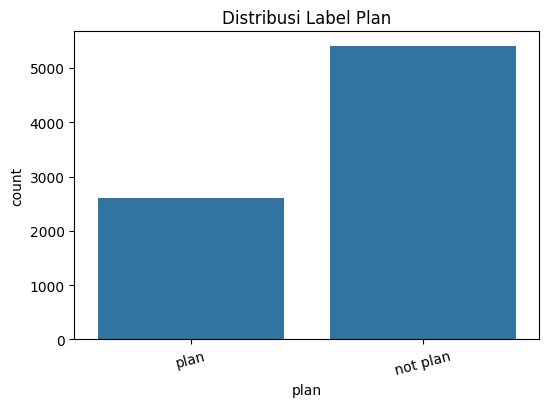

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='plan', data=df)
plt.title('Distribusi Label Plan')
plt.xticks(rotation=15)
plt.show()

In [ ]:
# mapping label -> kode untuk target
plan_cat = df['plan'].astype('category')
plan_classes = list(plan_cat.cat.categories)  # urutan kelas
df['plan'] = plan_cat.cat.codes  # ubah ke numerik

# fitur kategorikal lain (Gender, Encourage) → ubah ke kode juga
for col in ['gender', 'encourage']:
    if col in df.columns:
        df[col] = df[col].astype('category').cat.codes

df.head()

,student_id,gender,parent_income,iq,encourage,plan
0,4558,1,53900,118,0,1
1,4561,0,24900,87,1,0
2,4563,0,65800,93,1,0
3,4565,1,11440,117,0,1
4,4567,0,16700,102,1,0


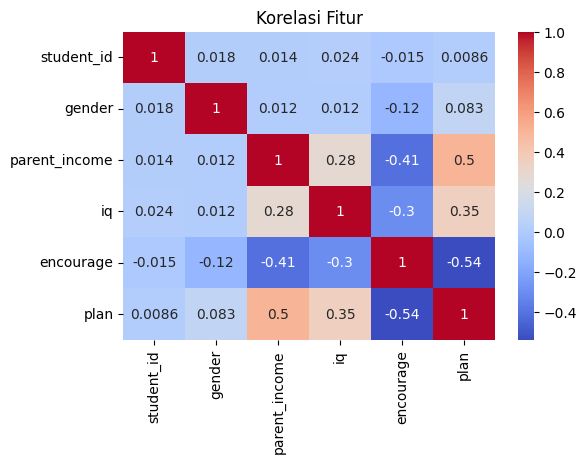

In [ ]:
# korelasi
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur')
plt.show()

In [ ]:
# Memilih fitur dan target
feature_cols = ['gender', 'parent_income', 'iq', 'encourage']
X = df [feature_cols]
y = df['plan']

In [ ]:
# Membagi data menjadi data latih dan data uji
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))

Jumlah data latih: 6400
Jumlah data uji: 1600


In [ ]:
# Membangun model
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
# Evaluasi
y_pred = dt.predict(X_test)

print("Akurasi:", round(accuracy_score(y_test, y_pred) *100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=plan_classes
))

Akurasi: 82.62 %

Confusion Matrix:
 [[960 121]
 [157 362]]

Classification Report:
               precision    recall  f1-score   support

    not plan       0.86      0.89      0.87      1081
        plan       0.75      0.70      0.72       519

    accuracy                           0.83      1600
   macro avg       0.80      0.79      0.80      1600
weighted avg       0.82      0.83      0.82      1600



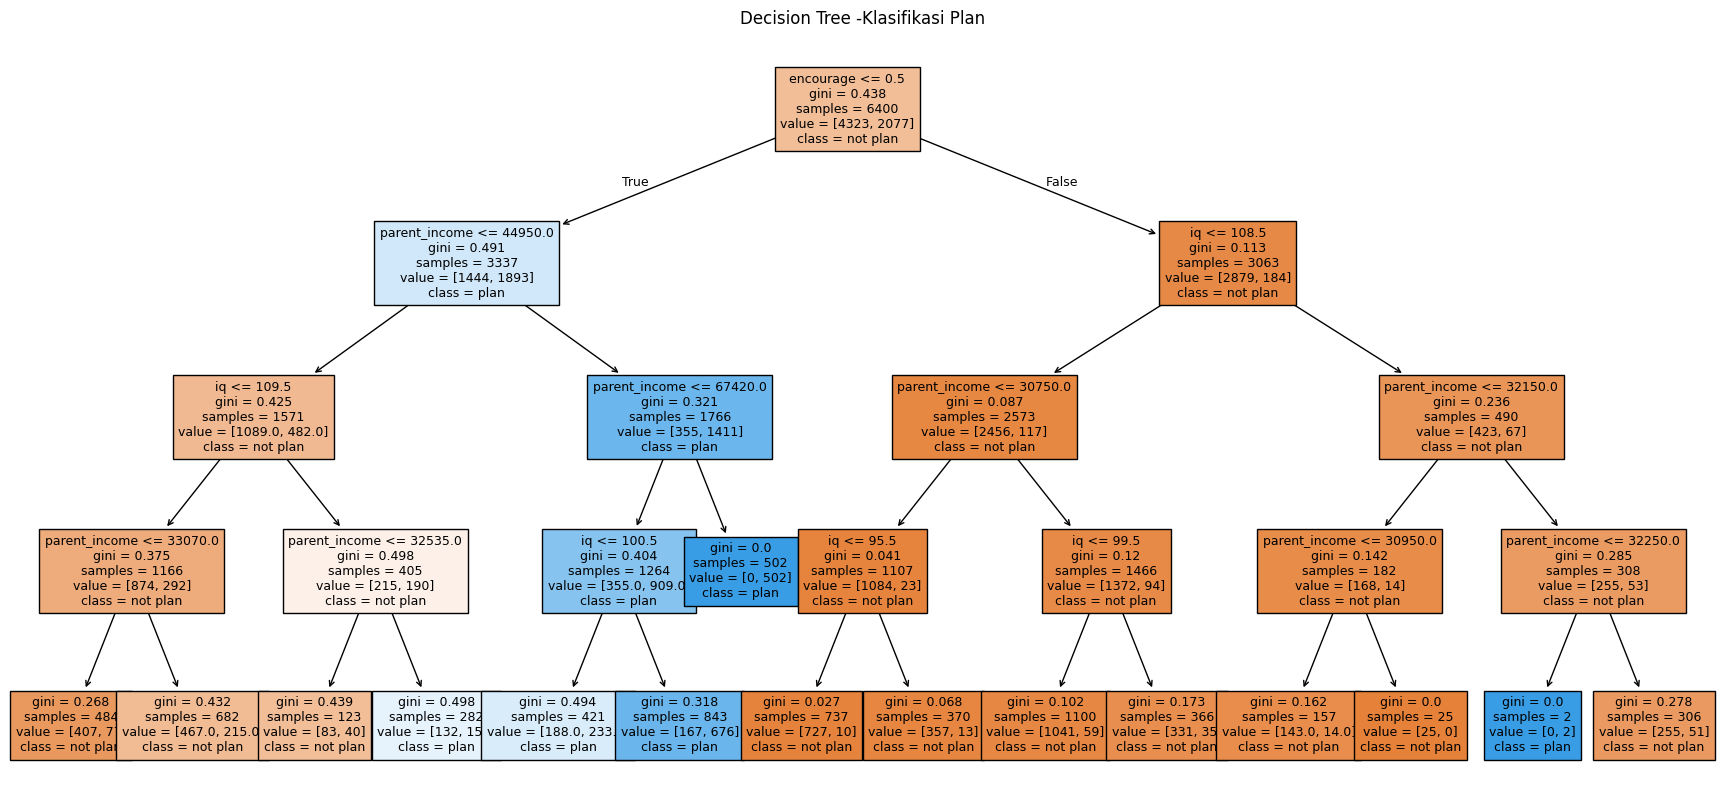

In [ ]:
# Visualisasi model
plt.figure(figsize=(22,10))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=plan_classes, # kembali ke nama kelas asli
    filled=True,
    fontsize=9
)
plt.title("Decision Tree -Klasifikasi Plan")
plt.show()

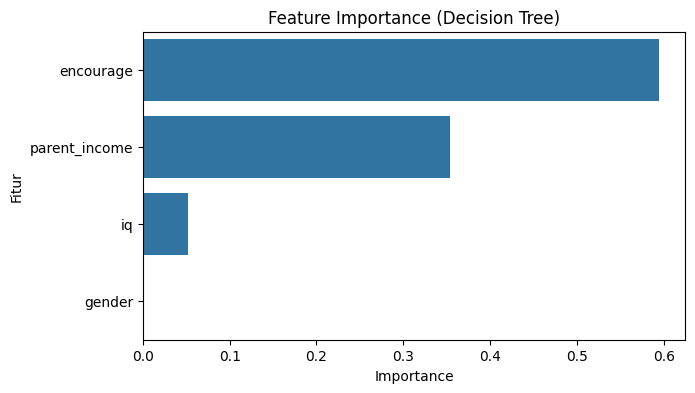

,0
encourage,0.594873
parent_income,0.353383
iq,0.051744
gender,0.000000


In [ ]:
# Fitur yang penting

imp = pd.Series(dt.feature_importances_, index=feature_cols).sort_values (ascending=False)
plt.figure(figsize=(7,4))
sns.barplot(x=imp, y=imp.index)
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.show()

imp

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

scores = {}
for d in range(2, 9):  # mencoba kedalaman 2 sampai 8
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    scores[d] = accuracy_score(y_test, m.predict(X_test))

# Menampilkan hasil akurasi tiap kedalaman
print("Akurasi per kedalaman:")
for depth, acc in scores.items():
    print(f"Depth {depth}: {acc:.4f}")

# Menentukan depth terbaik
best_d = max(scores, key=scores.get)
print("\nBest max_depth:", best_d, "| Acc:", round(scores[best_d]*100, 2), "%")

Akurasi per kedalaman:
Depth 2: 0.8187
Depth 3: 0.8187
Depth 4: 0.8263
Depth 5: 0.8150
Depth 6: 0.8263
Depth 7: 0.8256
Depth 8: 0.8225

Best max_depth: 4 | Acc: 82.62 %
